In [1]:
from functions import *

import pandas as pd
import numpy as np
from uncertainties import unumpy as unp
from scipy.stats import pearsonr
from scipy.stats import ks_2samp
import statsmodels.api as sm

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import seaborn as sns

palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = { 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import os
#Caminho para dados dos aglomerados
path = './Aglomerados/'

import warnings
warnings.filterwarnings('ignore')

In [2]:
df =pd.read_csv('Dados/results.csv', index_col='Cluster')
benchmark_subsample = pd.read_csv('Dados/benchmark_subsample.csv', index_col='Cluster')

print('full sample description')
print(df[['dist','age', 'FeH', 'Av', 'mass_total', 'n_members', 'bin_frac','e_bin_frac']].describe().round(2).T)

print('\nBenchmark subsample description')
print(benchmark_subsample[['dist','age', 'FeH', 'Av', 'mass_total', 'n_members' , 'bin_frac', 'e_bin_frac']].describe().round(2).T)


full sample description
            count    mean     std    min     25%     50%     75%      max
dist        771.0    1.75    1.00   0.14    0.94    1.64    2.37     6.87
age         771.0    8.18    0.64   6.67    7.79    8.25    8.68     9.59
FeH         771.0   -0.04    0.11  -0.37   -0.11   -0.04    0.03     0.43
Av          771.0    1.41    0.79   0.01    0.81    1.38    1.92     4.49
mass_total  771.0  544.47  447.32  61.00  245.00  413.00  678.00  3434.00
n_members   771.0  311.12  240.91  42.00  147.00  242.00  394.00  1548.00
bin_frac    771.0    0.58    0.11   0.23    0.51    0.58    0.66     0.90
e_bin_frac  771.0    0.15    0.07   0.03    0.09    0.13    0.18     0.46

Benchmark subsample description
            count    mean     std    min     25%     50%     75%      max
dist         94.0    0.63    0.29   0.14    0.39    0.61    0.79     1.37
age          94.0    8.24    0.57   6.74    7.80    8.31    8.63     9.58
FeH          94.0   -0.02    0.08  -0.23   -0.06   -0.0

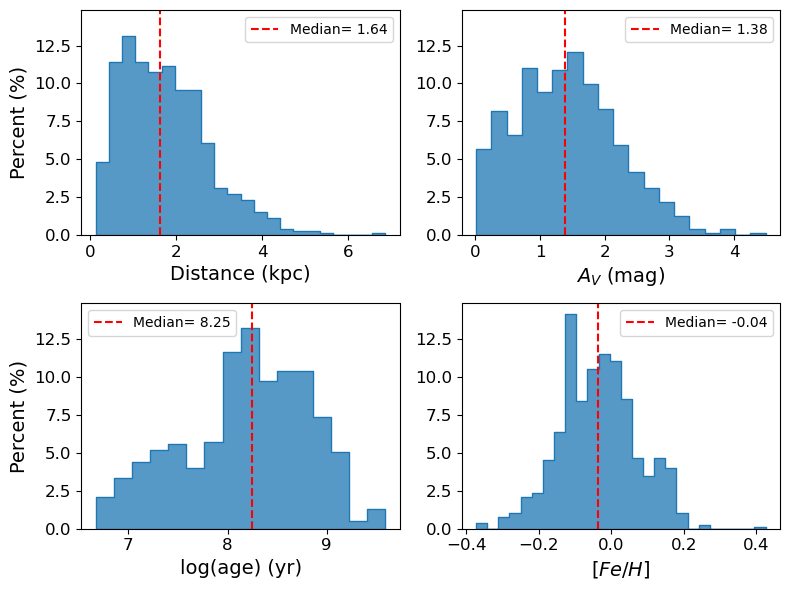

In [3]:
fig, axs = plt.subplots(2,2, figsize = (8,6), sharey=True)

sns.histplot(data=df, x='dist', ax = axs[0,0], stat='percent', element='step',)
axs[0,0].set_xlabel('Distance (kpc)', fontdict=font)
axs[0,0].axvline(x=df['dist'].median(), color='r',ls='--',  label = f'Median= {df.dist.median():.2f}')
axs[0,0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[0, 0].legend()


sns.histplot(data=df, x='Av', ax = axs[0,1], stat='percent', element='step')
axs[0,1].set_xlabel(r'$A_V$ (mag)', fontdict=font)
axs[0,1].axvline(x=df['Av'].median(), color='r',ls='--', label = f'Median= {df.Av.median():.2f}')
axs[0,1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[0, 1].legend()

sns.histplot(data=df, x='age', ax = axs[1,0], stat='percent', element='step')
axs[1,0].set_xlabel('log(age) (yr)', fontdict=font)
axs[1,0].axvline(x=df['age'].median(), color='r',ls='--', label = f'Median= {df.age.median():.2f}')
axs[1,0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1, 0].legend()

sns.histplot(data=df, x='FeH', ax = axs[1,1], stat='percent', element='step')
axs[1,1].set_xlabel(r'[$Fe/H$]', fontdict=font)
axs[1,1].axvline(x=df['FeH'].median(), color='r',ls='--', label = f'Median= {df.FeH.median():.2f}')
axs[1,1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1,1].legend()

axs[0,0].set_ylabel('Percent (%)', fontdict=font)
axs[1,0].set_ylabel('Percent (%)', fontdict=font)



plt.tight_layout()
plt.savefig('Figures/clusters_properties.png',bbox_inches='tight', dpi=300)
plt.show()

In [4]:
print(df[['bin_frac','e_bin_frac','bin_frac_0.5','e_bin_frac_0.5']].describe().round(2).T)

                count  mean   std   min   25%   50%   75%   max
bin_frac        771.0  0.58  0.11  0.23  0.51  0.58  0.66  0.90
e_bin_frac      771.0  0.15  0.07  0.03  0.09  0.13  0.18  0.46
bin_frac_0.5    771.0  0.40  0.11  0.13  0.32  0.40  0.47  0.75
e_bin_frac_0.5  771.0  0.15  0.08  0.02  0.09  0.13  0.19  0.42


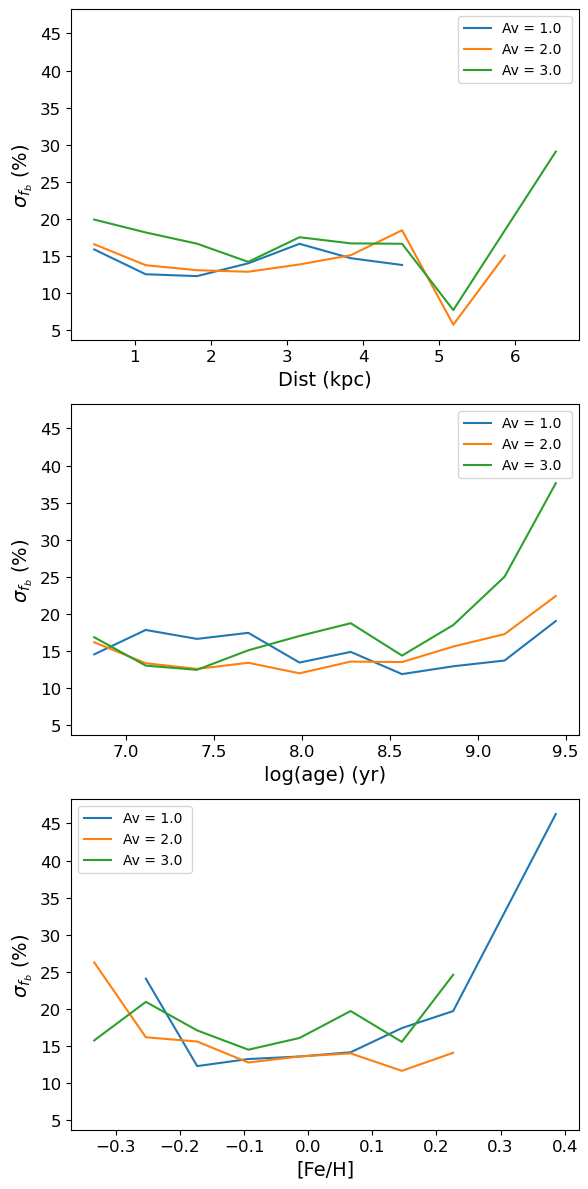

In [10]:
fig, axs = plt.subplots(3,1, figsize = (6,12), sharey=True)
aux = df.copy(deep=True)

# Agrupamento por faixas de extinção Av
aux['Av_group'] = pd.cut(aux['Av'], bins=[0, 1.0, 2.0, 3.0], labels=['Av = 1.0 ', 'Av = 2.0', 'Av = 3.0',])

# Divide a variável 'dist' (distância) em 10 faixas
aux['dist_bin'] = pd.cut(aux['dist'], bins=10)
aux['dist_center'] = aux['dist_bin'].apply(lambda x: x.mid)

# Agrupa por faixa de dist e grupo de Av, calcula média de e_bin_frac
grouped = aux.groupby(['Av_group', 'dist_center'])['e_bin_frac'].agg(['mean',]).reset_index()
sns.lineplot(data=grouped, x='dist_center', y=grouped['mean']*100, hue='Av_group', ax= axs[0])
axs[0].set_xlabel(r'Dist (kpc)', fontdict=font)



aux['age_bin'] = pd.cut(aux['age'], bins=10)
aux['age_center'] = aux['age_bin'].apply(lambda x: x.mid)

grouped = aux.groupby(['Av_group', 'age_center'])['e_bin_frac'].agg(['mean',]).reset_index()
grouped['mean'] = grouped['mean']*100


sns.lineplot(data=grouped, x='age_center', y=grouped['mean'], hue='Av_group', ax= axs[1])
axs[1].set_xlabel(r'log(age) (yr)', fontdict=font)

aux['FeH_bin'] = pd.cut(aux['FeH'], bins=10)
aux['FeH_center'] = aux['FeH_bin'].apply(lambda x: x.mid)


grouped = aux.groupby(['Av_group', 'FeH_center'])['e_bin_frac'].agg(['mean',]).reset_index()

sns.lineplot(data=grouped, x='FeH_center', y=grouped['mean']*100, hue='Av_group', ax= axs[2])
axs[2].set_xlabel(r'[Fe/H]', fontdict=font)

axs[0].set_ylabel(r'$\sigma_{f_b}$ (%)', fontdict= font)
axs[1].set_ylabel(r'$\sigma_{f_b}$ (%)', fontdict= font)
axs[2].set_ylabel(r'$\sigma_{f_b}$ (%)', fontdict= font)

for ax in axs:
    ax.tick_params(labelsize=labelsize)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('Figures/err_fb.png',bbox_inches='tight', dpi=300)
plt.show()


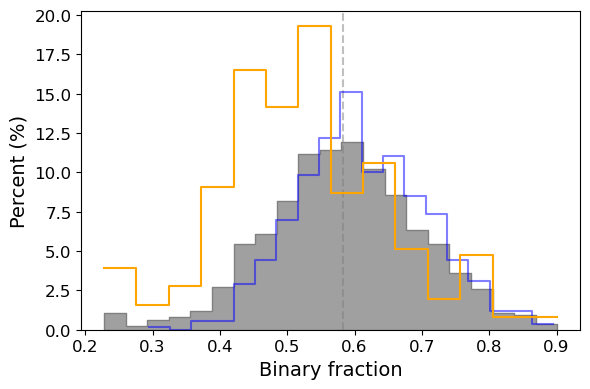

In [31]:
fig, ax= plt.subplots(figsize= (6,4))
sns.histplot(data=df, x='bin_frac', stat='percent', element='step', color='gray',)
plt.axvline(df.bin_frac.median(), ls='--', c='gray', alpha=0.5)
sns.histplot(data=df[df.Av>1], x='bin_frac', stat='percent', element='step', color='blue', fill = False, alpha=0.5)
sns.histplot(data=df[df.Av<=1], x='bin_frac', stat='percent', element='step', color='orange', fill = False,)

plt.xlabel('Binary fraction', fontdict=font)
plt.ylabel('Percent (%)', fontdict=font)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig('Figures/dist_fb.png',  dpi=300)
plt.show()


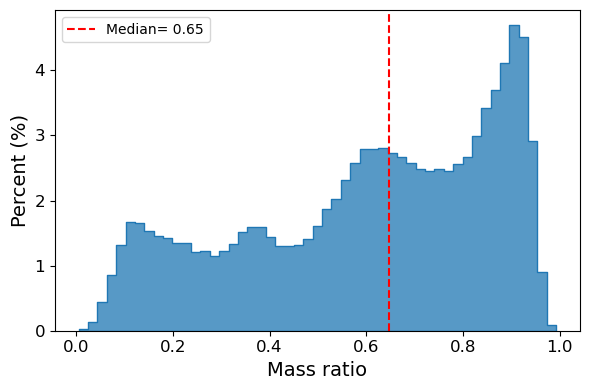

In [17]:
data = pd.read_csv('Dados/data.csv', index_col='Cluster')
    
median = data[data.q>0]['q'].median()
fig, ax= plt.subplots(figsize= (6,4))
sns.histplot(x=data[data.q>0]['q'], stat='percent', element='step')
plt.axvline(data[data.q>0]['q'].median(), ls='--', c='r', 
            label = f'Median= {median:.2f}')

plt.xlabel('Mass ratio', fontdict=font)
plt.ylabel('Percent (%)', fontdict=font)
ax.tick_params(labelsize=labelsize)
plt.tight_layout()
plt.legend(loc='upper left')
plt.savefig('Figures/dist_mass_ratio.png',  dpi=300)
plt.show()

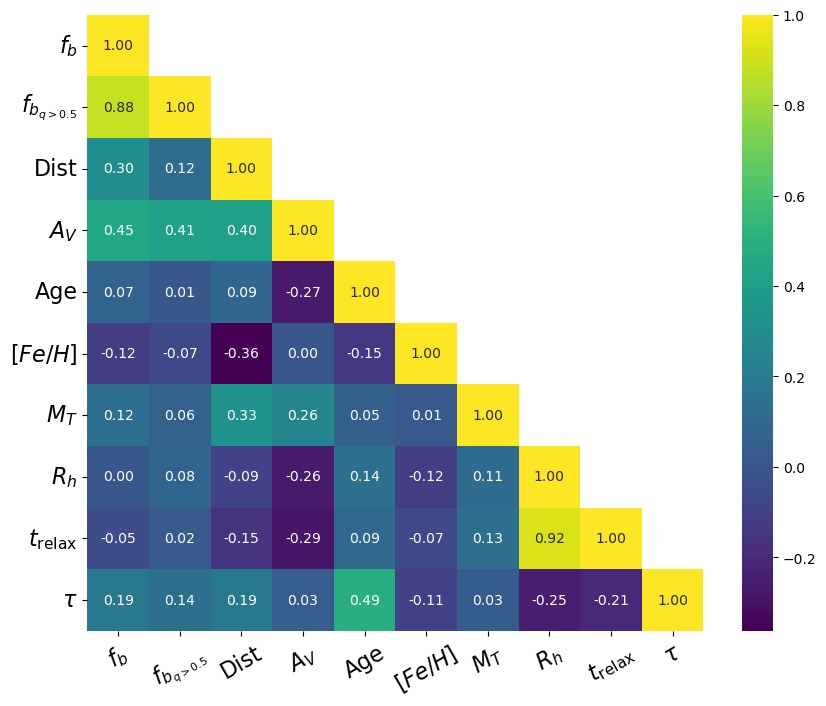

In [21]:
nome_vars = {
    'bin_frac': r'$f_b$',
    'bin_frac_0.5': r'$f_{b_{q>0.5}}$',
    'dist': r'Dist',
    'Av': r'$A_V$',
    'age': r'Age',
    'FeH': r'[$Fe/H$]',
    'mass_total': r'$M_T$',
    'rh': r'$R_h$',
    't_relax': r'$t_{\mathrm{relax}}$',
    'tau': r'$\tau$',
}

cols = list(nome_vars.keys())
corr = df[cols].corr()
corr.rename(index=nome_vars, columns=nome_vars, inplace=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig = plt.figure(figsize=(10, 8))
cmap = palette 

ax = sns.heatmap(corr, mask=mask, annot=True, cmap=cmap, fmt=".2f", square=True, cbar=True,)

for label in ax.get_xticklabels():
    label.set_fontsize(16)
    label.set_rotation(30) 

for label in ax.get_yticklabels():
    label.set_fontsize(16)
    label.set_rotation(0) 

plt.savefig('Figures/corr.png',bbox_inches='tight')
plt.show()

In [ ]:
benchmark_subsample